In [1]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.plots import plot_uncertainty_distributions, plot_combined_uncertainty_analysis
from lib.utils import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'pd_neuro'
analysis_name = 'pd_dyskinesia'
outcome_name = 'FutureDyskinesia'
build_ensemble_csv(analysis_name, outcome_name)


active_at_bl = pd.read_csv(f'../data/{dataset}/clusters/active_neuro_dyskinesia.csv')
all_patients = pd.read_csv(f'../data/{dataset}/X_neuroart_v4.csv')
# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.index = patients_stats['idx']

# remove patient in postion 87 from all_patients and active_at_bl because this patiente is never tested
all_patients = all_patients.drop(index=87)

# remove from full training preds the active patients at bl
non_active_idx = all_patients.index[~all_patients.index.isin(active_at_bl['Unnamed: 0'])]


all_patients_non_active = all_patients[all_patients.index.isin(non_active_idx)]

# filter out active patients at bl from the mean training predictions
patients_stats_filtered = patients_stats[patients_stats['idx'].isin(non_active_idx)]

# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats_filtered['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats_filtered['idx'].values)

Successfully aggregated 10500 predictions across 246 unique patients.


Baseline entropy: 0.8718686865491422


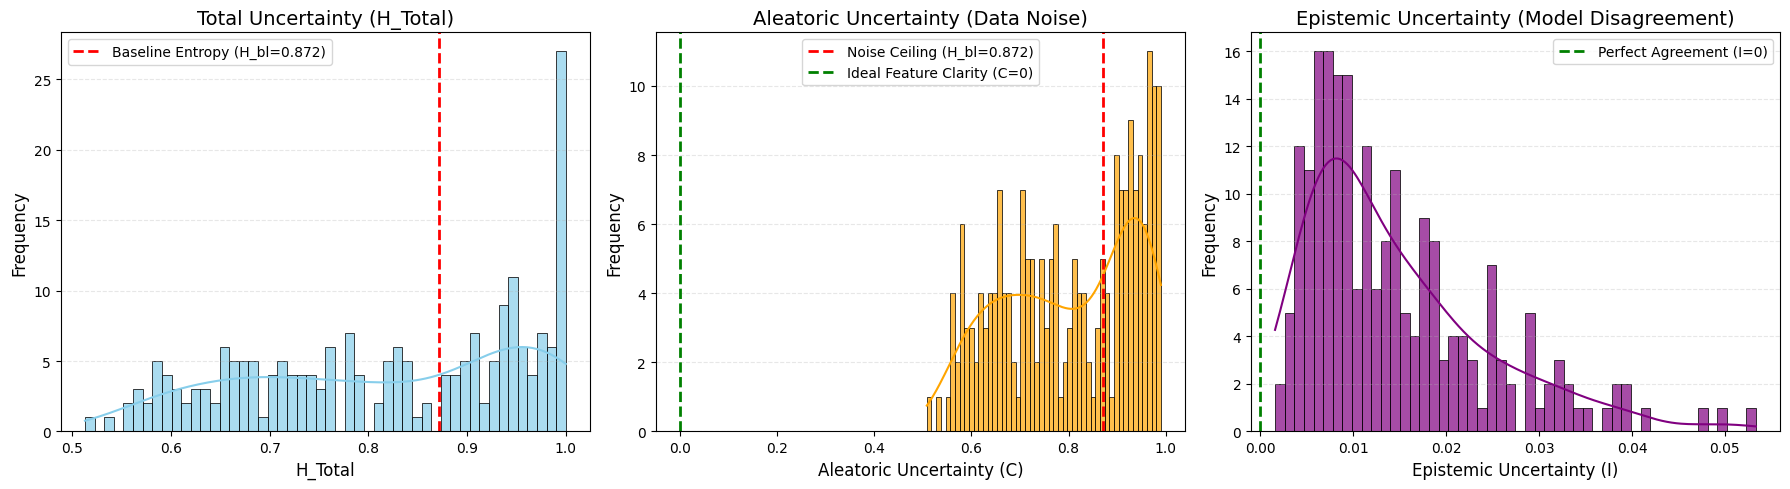

In [2]:
# Compute uncertainties for the non-active patients at baseline


uncertainty_results = compute_uncertainties(probs_raw_df)

# Create an explicit copy to avoid SettingWithCopyWarning
patients_stats_filtered = patients_stats_filtered.copy()

# 2. Add the results to your main stats table
patients_stats_filtered['H_Total'] = uncertainty_results['H_Total']
patients_stats_filtered['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
patients_stats_filtered['I_Epistemic'] = uncertainty_results['I_Epistemic']


# Compute the baseline risk (mean of probs_cal across all folds) for each patient and its uncertainty value 
proportion_positive = all_patients_non_active['FutureDyskinesia'].sum() / len(all_patients_non_active)
H_bl = -(proportion_positive * np.log2(proportion_positive + 1e-12) +
         (1 - proportion_positive) * np.log2(1 - proportion_positive + 1e-12))
print("Baseline entropy:", H_bl)



plot_uncertainty_distributions(
     uncertainty_results, 
     H_bl, 
     #save_path='../results/uncertainty/plots/uncertainty_distributions.png'
 )

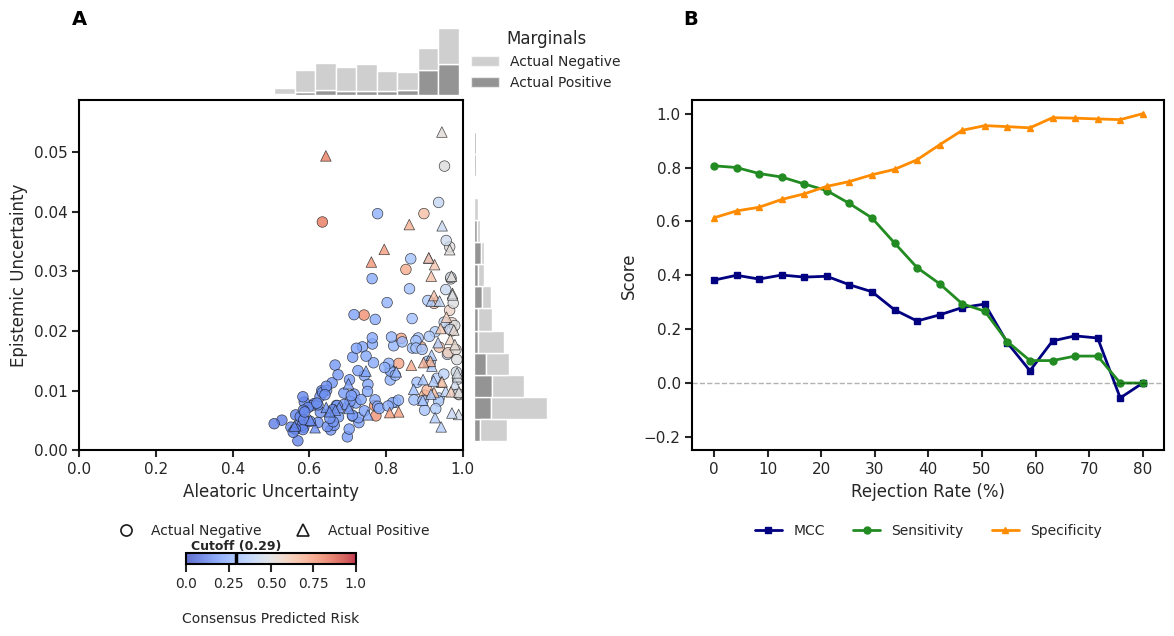

In [3]:
plot_combined_uncertainty_analysis(patients_stats_filtered, all_patients_non_active['FutureDyskinesia'])


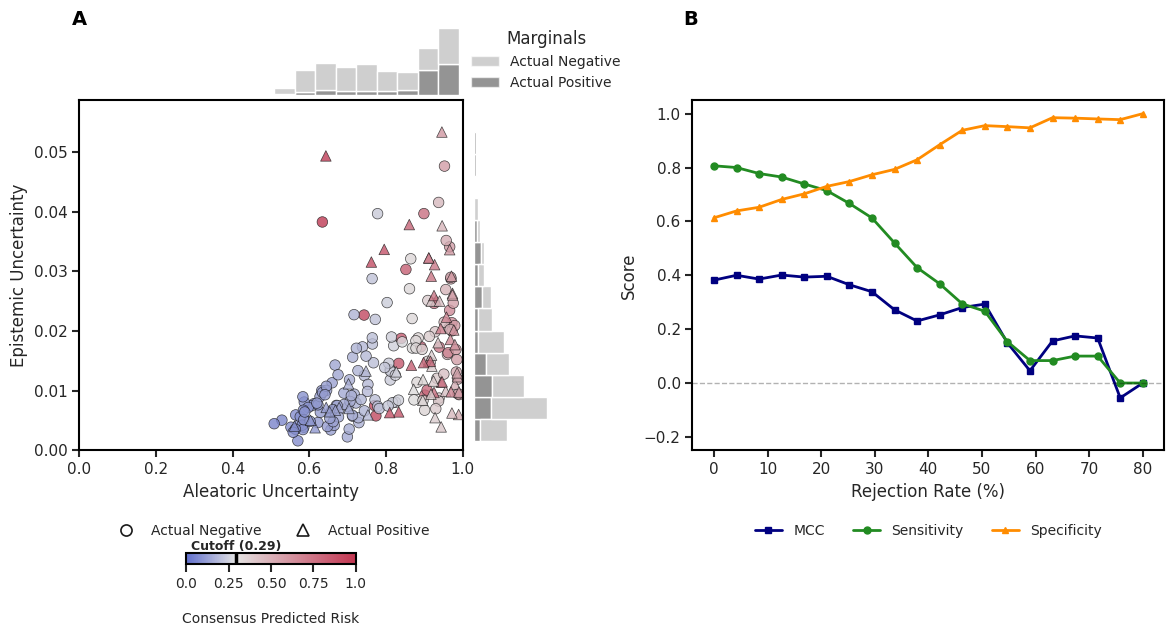

In [4]:
from lib.plots import plot_combined_uncertainty_analysis_v2


plot_combined_uncertainty_analysis_v2(patients_stats_filtered, all_patients_non_active['FutureDyskinesia'])

## Explore clinical data through GMM analysis
There's a clear separation between patients. The two scores agree on the number of clusters. For this PD dataset we are going to do GMM analysis to see how the two clusters differ in terms of clinical features. Finally we're going to see how rejection curves differ between the two clusters.

Number of original clinical features: 27
Optimal PCs according to the Kaiser Rule: 9

Top 5 Eigenvalues:
[4.28 2.9  1.9  1.65 1.4 ]


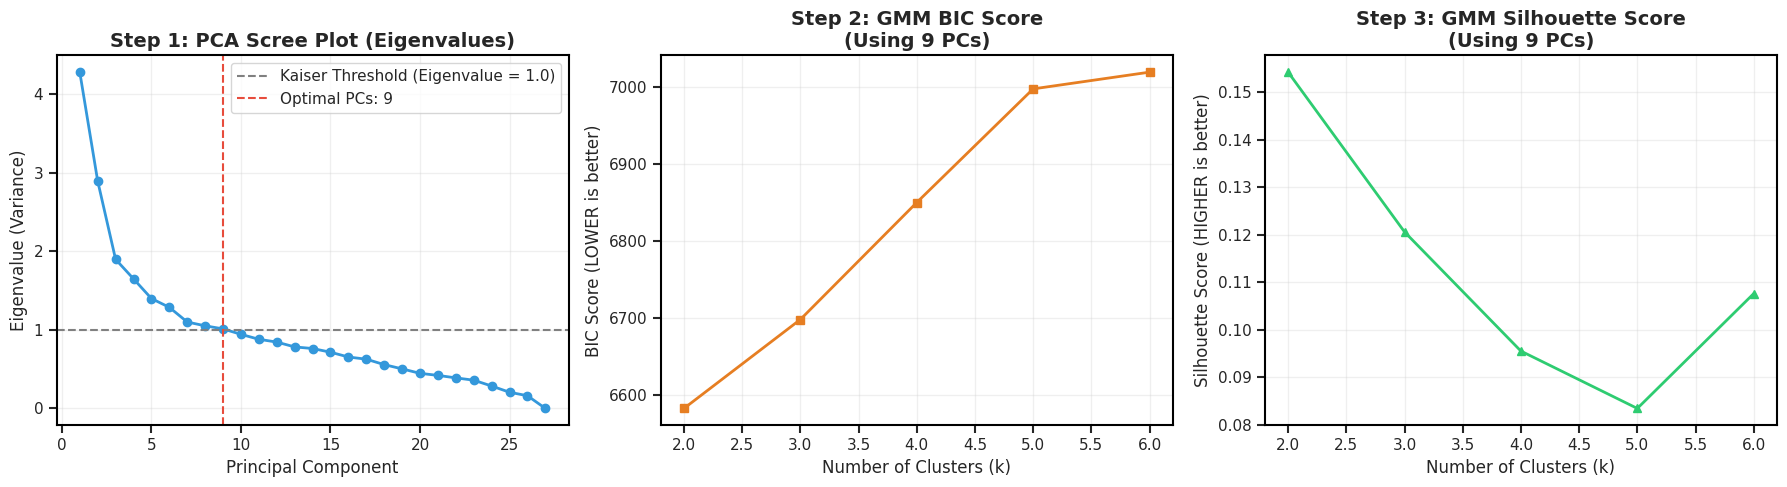


--- Optimization Results ---
1. Optimal PCs retained (Kaiser Rule, Eigenvalue > 1.0): 9
2. Best GMM model according to BIC (lowest complexity penalty): k = 2
3. Best GMM model according to Silhouette (highest separation): k = 2


In [5]:
from lib.clustering import optimize_pca_and_gmm_kaiser


X_clinical = all_patients_non_active.drop(columns=['FutureDyskinesia', 'PatientID', 'Center', 
                                                   'FutureMotorFluctuations', 'max_status_longi', 'FutureFalls', 
                                                   'FutureFreezing'])

optimize_pca_and_gmm_kaiser(X_clinical, max_clusters=6)

In [6]:
""" Run gmm clustering and analyze the two clusters"""

# 1. Prepare Data
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.mixture import GaussianMixture

from lib.clustering import profile_clinical_clusters


imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_clinical)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca_opt = PCA(n_components=9, random_state=42)
X_pca = pca_opt.fit_transform(X_scaled)

final_gmm = GaussianMixture(n_components=2, random_state=42, n_init=10)
clusters = final_gmm.fit_predict(X_pca)

cluster_probs = final_gmm.predict_proba(X_pca)

phenotype_labels = np.where(clusters == 0, 'Phenotype A (Predictable - advanced)', 'Phenotype B (Invisible - mild)')

patients_stats_filtered['Phenotype'] = phenotype_labels

clinical_profile = profile_clinical_clusters(X_clinical, patients_stats_filtered)

--- Clinical Signature of the Phenotypes ---
 Clinical_Feature  Mean_Phenotype_A  Mean_Phenotype_B P_Value
MotorFluctuations              0.38              0.02  <0.001
             ledd            449.56            164.35  <0.001
 DiseaseYearsAtBL              1.03              0.24  <0.001
         Freezing              0.27              0.00  <0.001
    LevodopaYears              4.30              1.15  <0.001
            Falls              0.26              0.00  <0.001
  CognitiveStatus              0.32              0.00  <0.001
              ICD              0.23              0.00  <0.001
   LevodopaBinary              0.87              0.53  <0.001
              H&Y              2.05              1.65  <0.001


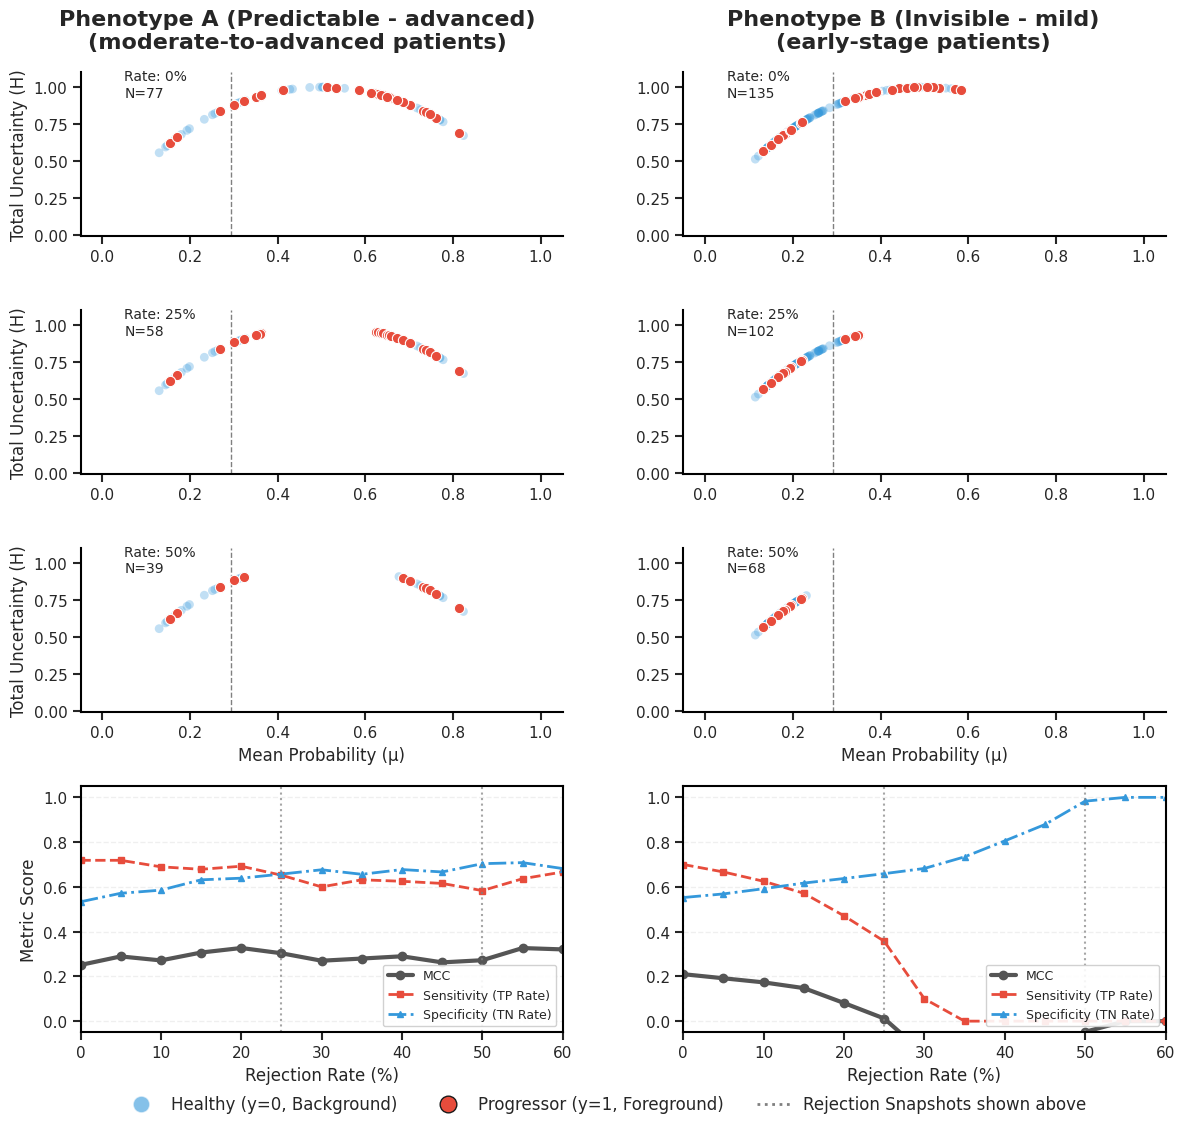

In [9]:
from lib.clustering import generate_forensic_dashboard


generate_forensic_dashboard(patients_stats_filtered, 'H_Total')

## Conditioned Classification Rejection Curves (CCRC)

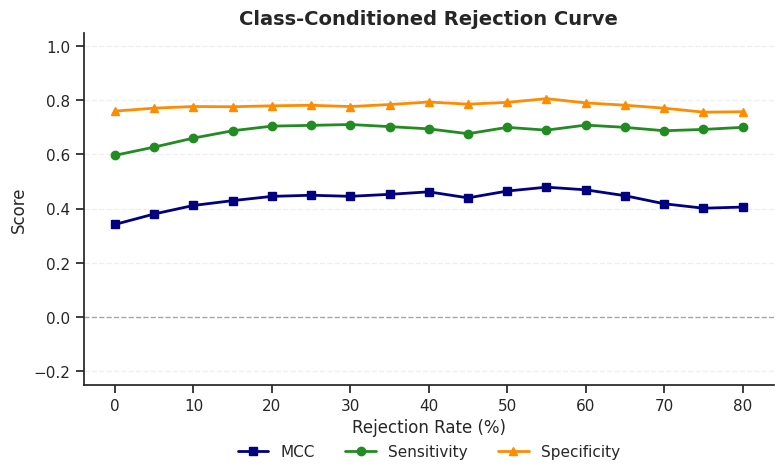

GLOBAL CLASS-CONDITIONED REJECTION: METRICS EVOLUTION
 Rejection (%)  Total Kept  TP  FP  TN  FN   MCC  Sensitivity  Specificity
             0         212  37  36 114  25 0.342        0.597        0.760
             5         203  37  33 111  22 0.380        0.627        0.771
            10         192  35  31 108  18 0.412        0.660        0.777
            15         182  33  30 104  15 0.429        0.688        0.776
            20         171  31  28  99  13 0.445        0.705        0.780
            25         160  29  26  93  12 0.449        0.707        0.782
            30         150  27  25  87  11 0.445        0.711        0.777
            35         139  26  22  80  11 0.453        0.703        0.784
            40         128  25  19  73  11 0.462        0.694        0.793
            45         118  23  18  66  11 0.440        0.676        0.786
            50         107  21  16  61   9 0.465        0.700        0.792
            55          96  20  13  54   9 0.4

In [13]:
from lib.plots import plot_class_conditioned_rejection_curve


optimal_threshold = all_patients['FutureDyskinesia'].mean()

class_cond_results = plot_class_conditioned_rejection_curve(
    patients_stats_filtered, 
    threshold=optimal_threshold, 
    uncertainty_col='H_Total',
    rates=np.linspace(0, 80, 17)
)